<a href="https://colab.research.google.com/github/sap-tarshi-ghosh/python_/blob/main/02_basic_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

loadin dataset

In [3]:
data = load_breast_cancer()

separating features and target

In [4]:
X = data.data
y = data.target

K fold cross validation

In [6]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

model selection

In [7]:
model = DecisionTreeClassifier(random_state=42)

storing accuracies from different folds

In [10]:
accuracies = []

performing kfold cross validation and training the model

In [11]:
for train_index, test_index in kf.split(X):

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    accuracies.append(acc)

    print("Fold Accuracy:", acc)

Fold Accuracy: 0.9473684210526315
Fold Accuracy: 0.9298245614035088
Fold Accuracy: 0.9035087719298246
Fold Accuracy: 0.9473684210526315
Fold Accuracy: 0.9380530973451328


result

In [12]:
print("average accuracy: ", np.mean(accuracies))

average accuracy:  0.9332246545567457


In [16]:
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

df = pd.concat([X, y], axis=1)

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


data class distribution

0 -> Malignant (Cancerous tumor)
1 -> Benign (Non-cancerous tumor)

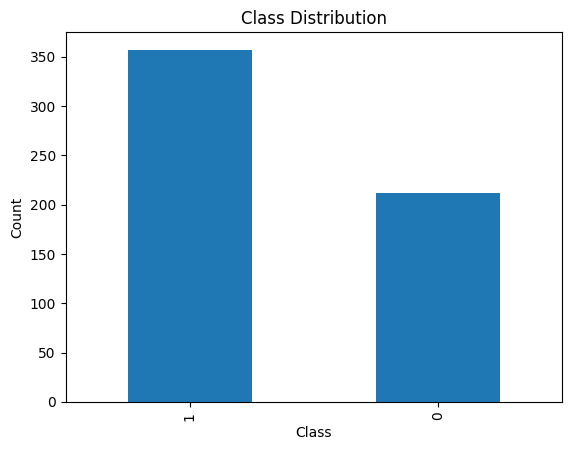

In [17]:
df["target"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()